# Dynamic Follow + Accel Personality Tuning Notebook\nInteractive sim for `FollowDistanceController` and `AccelPersonalityController`.\n\n**Workflow:**\n1. Run Section 1 (setup)\n2. Adjust sliders in Section 2 (dynamic follow) or Section 6 (accel controller)\n3. Run Section 3 (dynamic follow scenarios)\n4. Run Section 6 (accel controller plots)\n5. Run Section 4 (route replay — needs real route segments)\n6. Run Section 5 + 6e for summary stats

## Section 1 — Setup & Imports

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/media/kumar/data/sunnypilot/sunnypilot')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f8f8'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.size'] = 10

print('Setup OK')

Setup OK


## Section 2 — Tunable Constants
Edit these directly OR use ipywidgets sliders below.

In [2]:
# ── Personality bases ────────────────────────────────────────────────────────
PERSONALITY_BASE = {'relaxed': 1.75, 'standard': 1.45, 'aggressive': 1.25}
PERSONALITY_FLOOR = {'relaxed': 1.5,  'standard': 1.2,  'aggressive': 1.0}
PERSONALITY_CEILING = {'relaxed': 2.4, 'standard': 2.0,  'aggressive': 1.6}

# ── Modifier maxima ─────────────────────────────────────────── (budget: 0.40s)
JERK_DELTA_MAX    = 0.12   # max sec from jerk volatility
CUTIN_DELTA       = 0.10   # sec on cut-in event
CLOSING_DELTA_MAX = 0.08   # sec from closing vRel
ATAU_DELTA_MAX    = 0.05   # sec from high aLeadTau
ALEAD_DELTA_MAX   = 0.10   # sec from lead decel aLeadK

# ── Rate limits ──────────────────────────────────────────────────────────────
T_FOLLOW_RATE_UP   = 0.45  # sec/sec — snap toward danger
T_FOLLOW_RATE_DOWN = 0.08  # sec/sec — slow decay

# ── Grace period ─────────────────────────────────────────────────────────────
LEAD_LOST_GRACE_FRAMES = 10  # ~0.5s before clearing history on lead loss

# ── Jerk window ──────────────────────────────────────────────────────────────
JERK_WINDOW_FRAMES = 400   # ~20s
JERK_SIGMA_SCALE   = 5.0

# ── Cut-in ───────────────────────────────────────────────────────────────────
CUTIN_DECAY_FRAMES = 100   # ~5s

# ── Closing / aLead scales ────────────────────────────────────────────────────
CLOSING_VREL_SCALE = -2.0
ATAU_HIGH          = 2.0
ALEAD_DECEL_SCALE  = -1.0

DT_MDL = 0.05  # 20Hz model dt

print(f'Total modifier budget: {JERK_DELTA_MAX + CUTIN_DELTA + max(ALEAD_DELTA_MAX, CLOSING_DELTA_MAX) + ATAU_DELTA_MAX:.3f}s (limit 0.40s)')

Total modifier budget: 0.370s (limit 0.40s)


In [4]:
# ── Optional: interactive sliders (requires ipywidgets) ──────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display

    s_jerk   = widgets.FloatSlider(value=JERK_DELTA_MAX,    min=0.0, max=0.30, step=0.01, description='JERK_DELTA_MAX')
    s_cutin  = widgets.FloatSlider(value=CUTIN_DELTA,       min=0.0, max=0.30, step=0.01, description='CUTIN_DELTA')
    s_close  = widgets.FloatSlider(value=CLOSING_DELTA_MAX, min=0.0, max=0.30, step=0.01, description='CLOSING_MAX')
    s_atau   = widgets.FloatSlider(value=ATAU_DELTA_MAX,    min=0.0, max=0.15, step=0.01, description='ATAU_MAX')
    s_alead  = widgets.FloatSlider(value=ALEAD_DELTA_MAX,   min=0.0, max=0.30, step=0.01, description='ALEAD_MAX')
    s_rate_up   = widgets.FloatSlider(value=T_FOLLOW_RATE_UP,   min=0.05, max=2.0, step=0.05, description='RATE_UP')
    s_rate_down = widgets.FloatSlider(value=T_FOLLOW_RATE_DOWN, min=0.01, max=0.5,  step=0.01, description='RATE_DOWN')
    s_grace  = widgets.IntSlider(value=LEAD_LOST_GRACE_FRAMES, min=0, max=40, step=1, description='GRACE_FRAMES')

    budget_label = widgets.Label()

    def _update_globals(change=None):
        global JERK_DELTA_MAX, CUTIN_DELTA, CLOSING_DELTA_MAX, ATAU_DELTA_MAX, ALEAD_DELTA_MAX
        global T_FOLLOW_RATE_UP, T_FOLLOW_RATE_DOWN, LEAD_LOST_GRACE_FRAMES
        JERK_DELTA_MAX    = s_jerk.value
        CUTIN_DELTA       = s_cutin.value
        CLOSING_DELTA_MAX = s_close.value
        ATAU_DELTA_MAX    = s_atau.value
        ALEAD_DELTA_MAX   = s_alead.value
        T_FOLLOW_RATE_UP   = s_rate_up.value
        T_FOLLOW_RATE_DOWN = s_rate_down.value
        LEAD_LOST_GRACE_FRAMES = s_grace.value
        budget = JERK_DELTA_MAX + CUTIN_DELTA + max(ALEAD_DELTA_MAX, CLOSING_DELTA_MAX) + ATAU_DELTA_MAX
        budget_label.value = f'Budget: {budget:.3f}s  ({"OK" if budget <= 0.40 else "OVER LIMIT"})'  

    for s in [s_jerk, s_cutin, s_close, s_atau, s_alead, s_rate_up, s_rate_down, s_grace]:
        s.observe(_update_globals, names='value')

    _update_globals()
    display(widgets.VBox([
        widgets.Label('── Modifier Maxima ──'),
        s_jerk, s_cutin, s_close, s_atau, s_alead,
        widgets.Label('── Rate Limits ──'),
        s_rate_up, s_rate_down,
        widgets.Label('── Grace Period ──'),
        s_grace,
        budget_label,
    ]))
    print('Sliders active — adjusting updates globals. Re-run sim cells to apply.')
except ImportError:
    print('ipywidgets not installed — edit constants in cell above directly.')

Sliders active — adjusting updates globals. Re-run sim cells to apply.


## Section 3 — Simulator
Pure-Python re-implementation of FollowDistanceController using the globals above.
No Params/cereal needed — runs offline.

In [5]:
from collections import deque

class SimLead:
    def __init__(self, status=True, dRel=40.0, vLead=20.0, aLeadK=0.0, aLeadTau=0.5):
        self.status = status
        self.dRel   = dRel
        self.vLead  = vLead
        self.aLeadK = aLeadK
        self.aLeadTau = aLeadTau


class SimController:
    """Mirrors FollowDistanceController using notebook globals."""

    def __init__(self, personality='standard'):
        self._personality = personality
        self.current_t_follow = PERSONALITY_BASE[personality]
        self._alead_history = deque(maxlen=JERK_WINDOW_FRAMES)
        self._jerk_history  = deque(maxlen=JERK_WINDOW_FRAMES)
        self._prev_lead_status = False
        self._prev_drel = 0.0
        self._cutin_frames_remaining = 0
        self._cutin_confirm = 0
        self._lead_lost_grace = 0
        self._last_lead_target = None
        self.first_run = True
        # debug
        self.dbg_jerk_delta = 0.0
        self.dbg_cutin_delta = 0.0
        self.dbg_closing_delta = 0.0
        self.dbg_atau_delta = 0.0
        self.dbg_alead_delta = 0.0

    def step(self, v_ego, lead=None):
        target = self._compute_target(v_ego, lead)
        if self.first_run:
            self.current_t_follow = target
            self.first_run = False
            return float(self.current_t_follow)
        rate = T_FOLLOW_RATE_UP * DT_MDL if target > self.current_t_follow else T_FOLLOW_RATE_DOWN * DT_MDL
        self.current_t_follow = float(np.clip(target, self.current_t_follow - rate, self.current_t_follow + rate))
        return float(self.current_t_follow)

    def _compute_target(self, v_ego, lead):
        base  = PERSONALITY_BASE[self._personality]
        floor = PERSONALITY_FLOOR[self._personality]
        ceil  = PERSONALITY_CEILING[self._personality]

        if lead is None or not lead.status:
            self._lead_lost_grace = max(0, self._lead_lost_grace - 1)
            if self._lead_lost_grace == 0:
                self._update_no_lead()
                self._last_lead_target = None
                return float(np.clip(base, floor, ceil))
            if self._last_lead_target is not None:
                return self._last_lead_target
            return float(np.clip(base, floor, ceil))

        self._lead_lost_grace = LEAD_LOST_GRACE_FRAMES
        a_lead = float(lead.aLeadK)
        a_tau  = float(lead.aLeadTau)
        v_rel  = float(lead.vLead) - v_ego
        d_rel  = float(lead.dRel)
        status = bool(lead.status)

        self._update_history(a_lead, v_rel, status, d_rel)

        delta  = self._mod_jerk_volatility()
        delta += self._mod_cutin()
        delta += max(self._mod_alead(a_lead), self._mod_closing(v_rel))
        delta += self._mod_atau(a_tau)

        self._prev_lead_status = status
        self._prev_drel = d_rel

        result = float(np.clip(base + delta, floor, ceil))
        self._last_lead_target = result
        return result

    def _update_no_lead(self):
        self._prev_lead_status = False
        self._prev_drel = 0.0
        self._cutin_frames_remaining = 0
        self._cutin_confirm = 0
        self._alead_history.clear()
        self._jerk_history.clear()

    def _update_history(self, a_lead, v_rel, status, d_rel):
        if self._alead_history:
            self._jerk_history.append(abs((a_lead - self._alead_history[-1]) / DT_MDL))
        self._alead_history.append(a_lead)

        is_new_lead   = status and not self._prev_lead_status
        is_closing_jump = status and self._prev_lead_status and (self._prev_drel - d_rel) > 3.0

        if is_new_lead:
            self._cutin_confirm = 0
            self._cutin_frames_remaining = CUTIN_DECAY_FRAMES
        elif is_closing_jump:
            self._cutin_confirm += 1
            if self._cutin_confirm >= 2:
                self._cutin_frames_remaining = CUTIN_DECAY_FRAMES
        else:
            self._cutin_confirm = 0

        if self._cutin_frames_remaining > 0:
            self._cutin_frames_remaining -= 1

    def _mod_jerk_volatility(self):
        if len(self._jerk_history) < 10:
            self.dbg_jerk_delta = 0.0
            return 0.0
        sigma = float(np.std(self._jerk_history))
        delta = JERK_DELTA_MAX * float(np.clip(sigma / JERK_SIGMA_SCALE, 0.0, 1.0))
        self.dbg_jerk_delta = delta
        return delta

    def _mod_cutin(self):
        frac  = self._cutin_frames_remaining / CUTIN_DECAY_FRAMES
        delta = CUTIN_DELTA * frac
        self.dbg_cutin_delta = delta
        return delta

    def _mod_alead(self, a_lead):
        ratio = float(np.clip(a_lead / ALEAD_DECEL_SCALE, 0.0, 1.0))
        delta = ALEAD_DELTA_MAX * ratio
        self.dbg_alead_delta = delta
        return delta

    def _mod_closing(self, v_rel):
        ratio = float(np.clip(v_rel / CLOSING_VREL_SCALE, 0.0, 1.0))
        delta = CLOSING_DELTA_MAX * ratio
        self.dbg_closing_delta = delta
        return delta

    def _mod_atau(self, a_tau):
        ratio = float(np.clip((a_tau - ATAU_HIGH) / ATAU_HIGH, 0.0, 1.0))
        delta = ATAU_DELTA_MAX * ratio
        self.dbg_atau_delta = delta
        return delta


def mpc_obstacle_distance(v_ego, t_follow):
    """MPC safe obstacle distance formula."""
    return v_ego**2 / (2 * 2.5) + t_follow * v_ego + 6


print('SimController ready.')

SimController ready.


### 3a — Stop & Go Scenario
Simulates: lead present → lead lost (radar flip jitter) → lead returns, repeatedly.

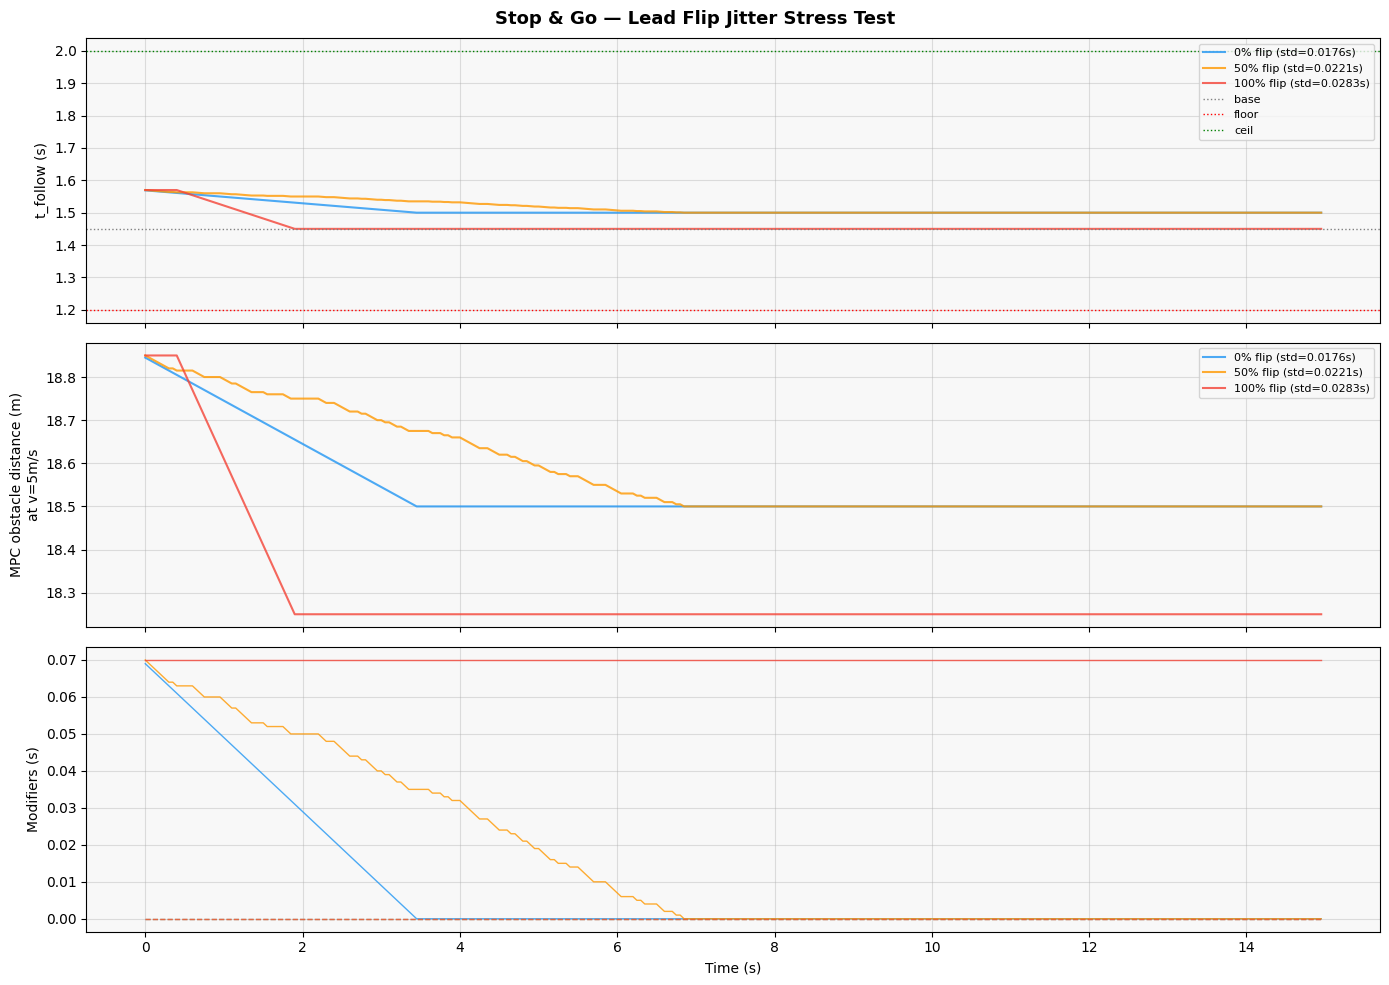

Budget check: 0.380s total


In [7]:
def run_sng_scenario(flip_rate_pct=100, v_ego=5.0, n_frames=300):
    """flip_rate_pct: 0=stable lead, 100=alternating every frame"""
    c = SimController('standard')
    lead = SimLead(dRel=15.0, vLead=v_ego, aLeadK=-0.5)

    # Warm up 30 frames with stable lead
    for _ in range(30):
        c.step(v_ego, lead)

    times, t_follows, obstacles = [], [], []
    dbg_jerk, dbg_cutin, dbg_alead = [], [], []

    for i in range(n_frames):
        t = i * DT_MDL
        use_lead = lead if (np.random.rand() * 100 >= flip_rate_pct) else None
        tf = c.step(v_ego, use_lead)
        times.append(t)
        t_follows.append(tf)
        obstacles.append(mpc_obstacle_distance(v_ego, tf))
        dbg_jerk.append(c.dbg_jerk_delta)
        dbg_cutin.append(c.dbg_cutin_delta)
        dbg_alead.append(c.dbg_alead_delta)

    return np.array(times), np.array(t_follows), np.array(obstacles), np.array(dbg_jerk), np.array(dbg_cutin), np.array(dbg_alead)


np.random.seed(42)
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Stop & Go — Lead Flip Jitter Stress Test', fontsize=13, fontweight='bold')

colors = {'0%': '#2196F3', '50%': '#FF9800', '100%': '#F44336'}

for flip_pct, color in [(0, '#2196F3'), (50, '#FF9800'), (100, '#F44336')]:
    t, tf, obs, jerk, cutin, alead = run_sng_scenario(flip_rate_pct=flip_pct, v_ego=5.0)
    label = f'{flip_pct}% flip (std={tf.std():.4f}s)'
    axes[0].plot(t, tf, color=color, alpha=0.8, label=label, linewidth=1.5)
    axes[1].plot(t, obs, color=color, alpha=0.8, label=label, linewidth=1.5)
    axes[2].plot(t, jerk, color=color, alpha=0.6, linewidth=1, linestyle='--')
    axes[2].plot(t, cutin, color=color, alpha=0.8, linewidth=1)

axes[0].set_ylabel('t_follow (s)')
axes[0].axhline(PERSONALITY_BASE['standard'], color='gray', linestyle=':', linewidth=1, label='base')
axes[0].axhline(PERSONALITY_FLOOR['standard'], color='red', linestyle=':', linewidth=1, label='floor')
axes[0].axhline(PERSONALITY_CEILING['standard'], color='green', linestyle=':', linewidth=1, label='ceil')
axes[0].legend(fontsize=8)

axes[1].set_ylabel('MPC obstacle distance (m)\nat v=5m/s')
axes[1].legend(fontsize=8)

axes[2].set_ylabel('Modifiers (s)')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

print(f'Budget check: {JERK_DELTA_MAX + CUTIN_DELTA + max(ALEAD_DELTA_MAX, CLOSING_DELTA_MAX) + ATAU_DELTA_MAX:.3f}s total')

### 3b — Highway Steady Follow
Stable lead at 55mph — measures t_follow stability and obstacle distance stability.

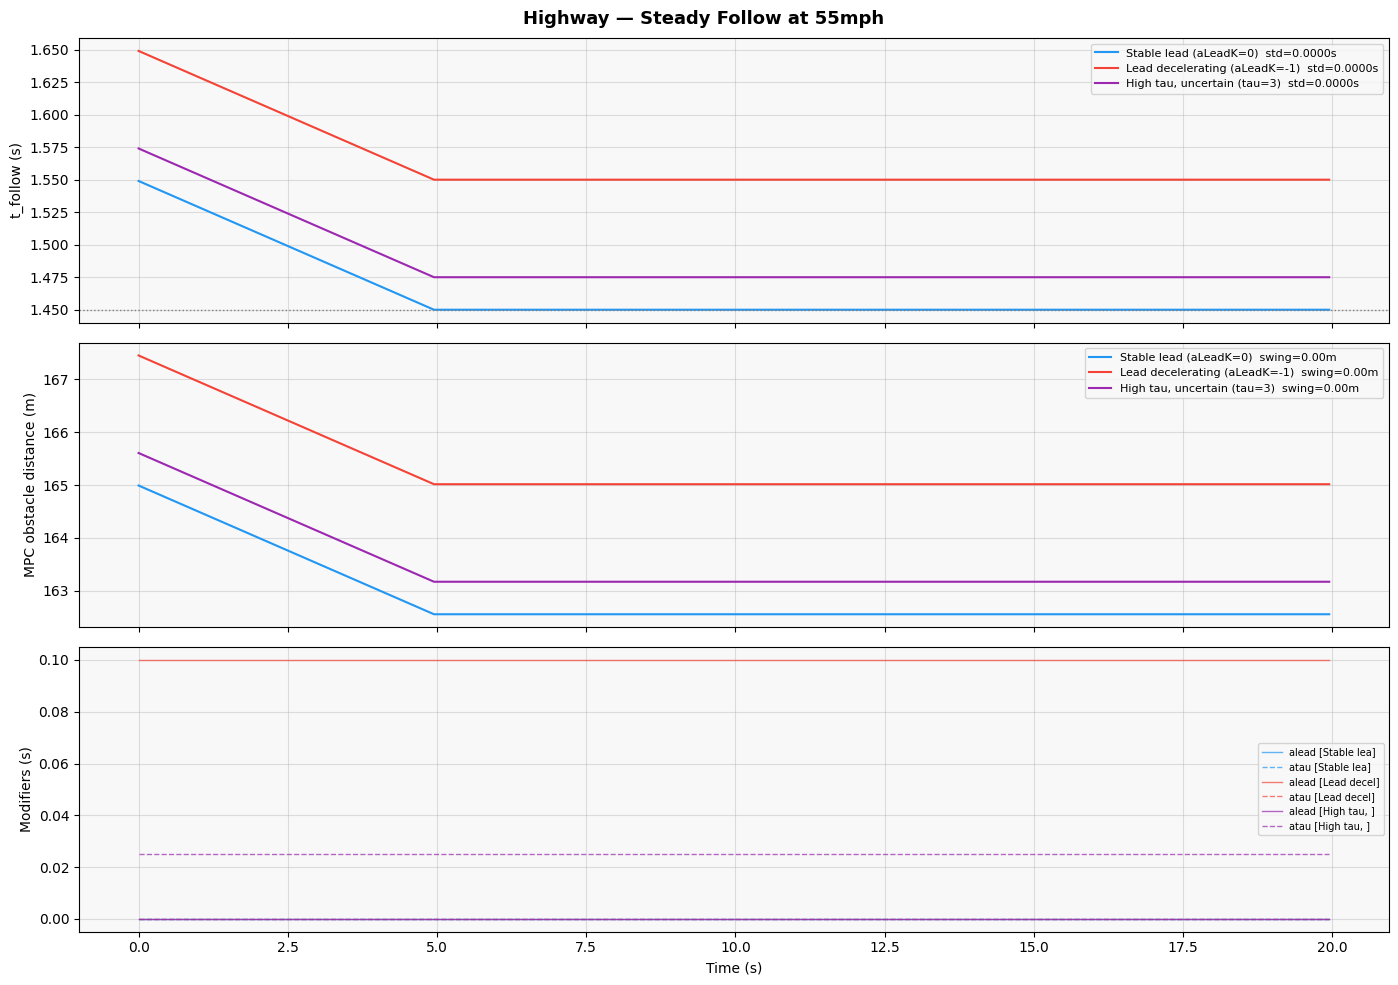

In [8]:
def run_highway_scenario(v_ego_mph=55, aLeadK=0.0, aLeadTau=0.5, n_frames=400):
    v_ego = v_ego_mph * 0.44704
    c = SimController('standard')
    lead = SimLead(dRel=40.0, vLead=v_ego, aLeadK=aLeadK, aLeadTau=aLeadTau)

    times, t_follows, obstacles = [], [], []
    dbg_alead, dbg_closing, dbg_atau = [], [], []

    for i in range(n_frames):
        tf = c.step(v_ego, lead)
        times.append(i * DT_MDL)
        t_follows.append(tf)
        obstacles.append(mpc_obstacle_distance(v_ego, tf))
        dbg_alead.append(c.dbg_alead_delta)
        dbg_closing.append(c.dbg_closing_delta)
        dbg_atau.append(c.dbg_atau_delta)

    return (np.array(times), np.array(t_follows), np.array(obstacles),
            np.array(dbg_alead), np.array(dbg_closing), np.array(dbg_atau))


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Highway — Steady Follow at 55mph', fontsize=13, fontweight='bold')

scenarios = [
    ('Stable lead (aLeadK=0)',      dict(aLeadK=0.0,  aLeadTau=0.5), '#2196F3'),
    ('Lead decelerating (aLeadK=-1)', dict(aLeadK=-1.0, aLeadTau=0.5), '#F44336'),
    ('High tau, uncertain (tau=3)',  dict(aLeadK=0.0,  aLeadTau=3.0), '#9C27B0'),
]

for label, kwargs, color in scenarios:
    t, tf, obs, al, cl, at = run_highway_scenario(**kwargs)
    tf_steady = tf[100:]  # skip warmup
    obs_swing = obs[100:].max() - obs[100:].min()
    axes[0].plot(t, tf, color=color, label=f'{label}  std={tf_steady.std():.4f}s', linewidth=1.5)
    axes[1].plot(t, obs, color=color, label=f'{label}  swing={obs_swing:.2f}m', linewidth=1.5)
    axes[2].plot(t, al, color=color, linewidth=1, linestyle='-',  label=f'alead [{label[:10]}]', alpha=0.7)
    axes[2].plot(t, at, color=color, linewidth=1, linestyle='--', label=f'atau [{label[:10]}]',  alpha=0.7)

axes[0].axhline(PERSONALITY_BASE['standard'], color='gray', linestyle=':', linewidth=1)
axes[0].set_ylabel('t_follow (s)')
axes[0].legend(fontsize=8)

axes[1].set_ylabel('MPC obstacle distance (m)')
axes[1].legend(fontsize=8)

axes[2].set_ylabel('Modifiers (s)')
axes[2].set_xlabel('Time (s)')
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

### 3c — Cut-In Detection
Shows: new lead fires immediately, dRel jump requires 2 frames.

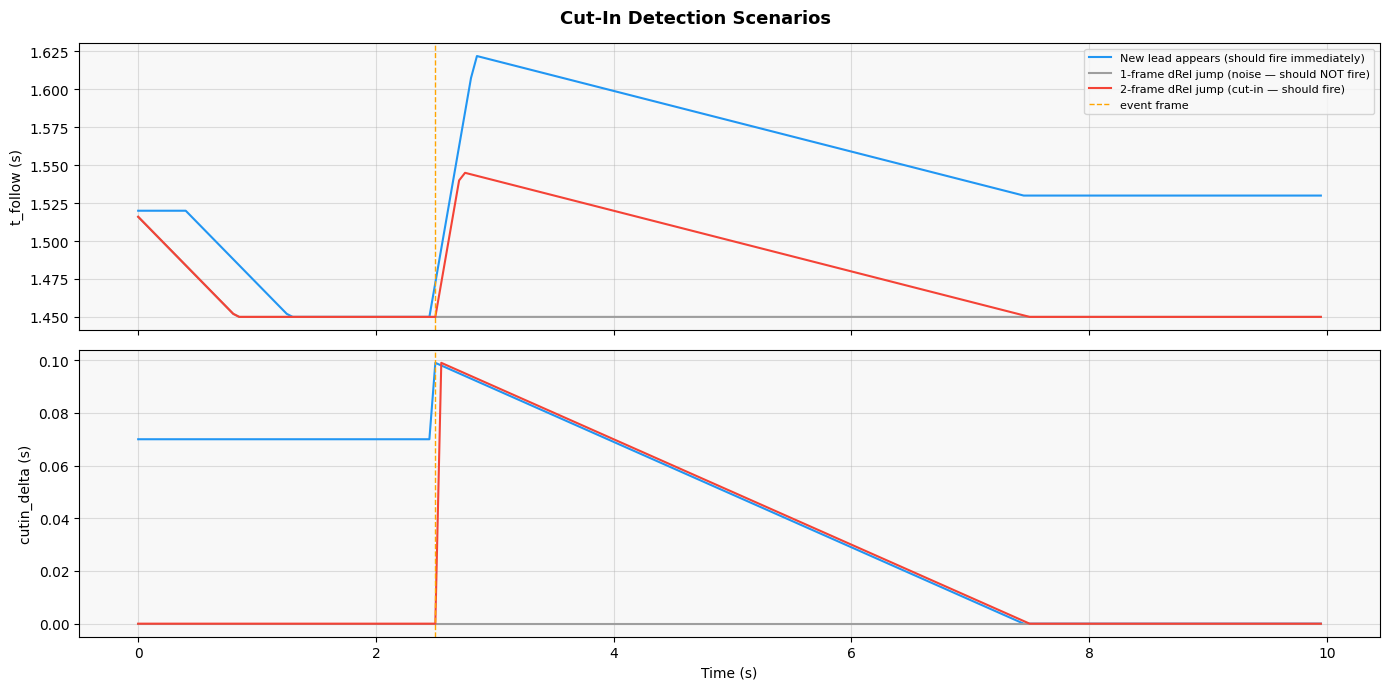

In [9]:
def run_cutin_scenario(scenario='new_lead', v_ego=15.0, n_frames=200):
    c = SimController('standard')
    lead_stable = SimLead(dRel=40.0, vLead=v_ego, aLeadK=0.0)

    # Warmup with stable lead
    for _ in range(30):
        c.step(v_ego, lead_stable)
    c._cutin_frames_remaining = 0

    times, t_follows, cutin_dbg = [], [], []
    cutin_event_frame = 50

    for i in range(n_frames):
        t = i * DT_MDL
        if scenario == 'new_lead':
            # No lead for frames 0-49, new lead at frame 50
            if i < cutin_event_frame:
                c.step(v_ego, None)
                lead_in = None
            else:
                lead_in = SimLead(dRel=25.0, vLead=v_ego - 3, aLeadK=0.0)
                c.step(v_ego, lead_in)
        elif scenario == 'drel_jump_1frame':
            # Single frame dRel jump (noise) — should NOT trigger
            if i == cutin_event_frame:
                lead_in = SimLead(dRel=34.0, vLead=v_ego)
            else:
                lead_in = lead_stable
            c.step(v_ego, lead_in)
        elif scenario == 'drel_jump_2frame':
            # Two consecutive frames of dRel jump — should trigger
            if i == cutin_event_frame:
                lead_in = SimLead(dRel=34.0, vLead=v_ego)
            elif i == cutin_event_frame + 1:
                lead_in = SimLead(dRel=30.0, vLead=v_ego)
            else:
                lead_in = lead_stable
            c.step(v_ego, lead_in)

        times.append(t)
        t_follows.append(c.current_t_follow)
        cutin_dbg.append(c.dbg_cutin_delta)

    return np.array(times), np.array(t_follows), np.array(cutin_dbg)


fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Cut-In Detection Scenarios', fontsize=13, fontweight='bold')

scenarios = [
    ('new_lead',       '#2196F3', 'New lead appears (should fire immediately)'),
    ('drel_jump_1frame', '#9E9E9E', '1-frame dRel jump (noise — should NOT fire)'),
    ('drel_jump_2frame', '#F44336', '2-frame dRel jump (cut-in — should fire)'),
]

for scen, color, label in scenarios:
    t, tf, cutin = run_cutin_scenario(scen)
    axes[0].plot(t, tf, color=color, label=label, linewidth=1.5)
    axes[1].plot(t, cutin, color=color, linewidth=1.5)

axes[0].axvline(50 * DT_MDL, color='orange', linestyle='--', linewidth=1, label='event frame')
axes[0].set_ylabel('t_follow (s)')
axes[0].legend(fontsize=8)

axes[1].axvline(50 * DT_MDL, color='orange', linestyle='--', linewidth=1)
axes[1].set_ylabel('cutin_delta (s)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

### 3d — Modifier Budget Breakdown
Shows max contribution of each modifier at current constants.

In [ ]:
modifiers = {
    'JERK_DELTA_MAX':    JERK_DELTA_MAX,
    'CUTIN_DELTA':       CUTIN_DELTA,
    'ALEAD_DELTA_MAX':   ALEAD_DELTA_MAX,
    'CLOSING_DELTA_MAX': CLOSING_DELTA_MAX,
    'ATAU_DELTA_MAX':    ATAU_DELTA_MAX,
}

# alead and closing are max(a, b) — show them as competing
combined_max = max(ALEAD_DELTA_MAX, CLOSING_DELTA_MAX)
effective = {
    'JERK':    JERK_DELTA_MAX,
    'CUTIN':   CUTIN_DELTA,
    'ALEAD\n(max w/ CLOSING)': combined_max,
    'ATAU':    ATAU_DELTA_MAX,
}
budget_total = sum(effective.values())

v_ego_55 = 55 * 0.44704
base_obs  = mpc_obstacle_distance(v_ego_55, PERSONALITY_BASE['standard'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Modifier Budget & MPC Obstacle Impact @ 55mph', fontsize=13, fontweight='bold')

colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = axes[0].bar(effective.keys(), effective.values(), color=colors_bar, alpha=0.8)
axes[0].axhline(0.40, color='red', linestyle='--', linewidth=1.5, label='0.40s limit')
axes[0].axhline(budget_total, color='orange', linestyle=':', linewidth=1.5, label=f'Total: {budget_total:.3f}s')
for bar, val in zip(bars, effective.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{val:.3f}s', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Max modifier (s)')
axes[0].set_title('Modifier Maxima')
axes[0].legend()

# Obstacle distance impact
t_range = np.linspace(PERSONALITY_FLOOR['standard'], PERSONALITY_CEILING['standard'], 100)
obs_range = mpc_obstacle_distance(v_ego_55, t_range)
axes[1].plot(t_range, obs_range, color='#2196F3', linewidth=2)
axes[1].axvline(PERSONALITY_BASE['standard'], color='gray', linestyle=':', label='base')
axes[1].axvline(PERSONALITY_BASE['standard'] + budget_total, color='orange', linestyle='--', label=f'base+budget ({budget_total:.3f}s)')
axes[1].axvline(PERSONALITY_FLOOR['standard'], color='red', linestyle=':', linewidth=1, label='floor')
axes[1].axvline(PERSONALITY_CEILING['standard'], color='green', linestyle=':', linewidth=1, label='ceil')
obs_at_base   = mpc_obstacle_distance(v_ego_55, PERSONALITY_BASE['standard'])
obs_at_budget = mpc_obstacle_distance(v_ego_55, PERSONALITY_BASE['standard'] + budget_total)
axes[1].annotate(f'{obs_at_budget - obs_at_base:.1f}m swing', 
                 xy=(PERSONALITY_BASE['standard'] + budget_total/2, (obs_at_base + obs_at_budget)/2),
                 ha='center', fontsize=10, color='orange')
axes[1].set_xlabel('t_follow (s)')
axes[1].set_ylabel('MPC obstacle distance (m)')
axes[1].set_title('Obstacle Distance Impact @ 55mph')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Budget total: {budget_total:.3f}s  |  Obstacle swing: {obs_at_budget - obs_at_base:.2f}m @ 55mph')

## Section 4 — Route Replay
Load real route segments and compare t_follow behavior against simulation.
Requires `openpilot.tools.lib.logreader`.

In [ ]:
# Routes to compare — paste segment IDs here
ROUTES_BASELINE = [
    # '550a71ee4c7a7fbe/ROUTE_ID_HERE',
]
ROUTES_NEW = [
    # '550a71ee4c7a7fbe/NEW_ROUTE_ID_HERE',
]

if not ROUTES_BASELINE:
    print('No routes configured. Add segment IDs to ROUTES_BASELINE above.')
else:
    from openpilot.tools.lib.logreader import LogReader

    def load_long_data(routes, label=''):
        all_data = []
        for route in routes:
            print(f'Loading {route[-20:]}...')
            lr = LogReader(route)
            last_vego = None
            last_aego = None
            t0 = None
            for msg in lr:
                w = msg.which()
                if w == 'carState':
                    last_vego = msg.carState.vEgo
                    last_aego = msg.carState.aEgo
                elif w == 'longitudinalPlan' and last_vego is not None:
                    if t0 is None:
                        t0 = msg.logMonoTime * 1e-9
                    t = msg.logMonoTime * 1e-9 - t0
                    all_data.append((t, last_vego, last_aego))
        if not all_data:
            print(f'No longitudinalPlan data in {label}')
            return None
        arr = np.array(all_data)
        print(f'{label}: {len(arr)} samples')
        return arr

    baseline = load_long_data(ROUTES_BASELINE, 'baseline')
    if ROUTES_NEW:
        new_data = load_long_data(ROUTES_NEW, 'new')
    else:
        new_data = None

    if baseline is not None:
        fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
        fig.suptitle('Route Replay — Longitudinal Accel Distribution', fontsize=13, fontweight='bold')

        axes[0].plot(baseline[:, 0], baseline[:, 2], color='#2196F3', alpha=0.6, linewidth=0.8, label='baseline')
        if new_data is not None:
            axes[0].plot(new_data[:, 0], new_data[:, 2], color='#F44336', alpha=0.6, linewidth=0.8, label='new')
        axes[0].set_ylabel('aEgo (m/s²)')
        axes[0].axhline(0, color='gray', linewidth=0.5)
        axes[0].legend()

        # Brake reversal count (sign changes in aEgo)
        def reversal_count(accel):
            signs = np.sign(accel)
            return int(np.sum(np.abs(np.diff(signs[signs != 0])) > 0))

        r_base = reversal_count(baseline[:, 2])
        axes[1].hist(baseline[:, 2], bins=80, color='#2196F3', alpha=0.6, label=f'baseline (reversals={r_base})')
        if new_data is not None:
            r_new = reversal_count(new_data[:, 2])
            axes[1].hist(new_data[:, 2], bins=80, color='#F44336', alpha=0.6, label=f'new (reversals={r_new})')
        axes[1].set_xlabel('aEgo (m/s²)')
        axes[1].set_ylabel('Count')
        axes[1].legend()

        plt.tight_layout()
        plt.show()

## Section 5 — Summary Stats
Quick table of current constants vs targets.

In [ ]:
v55 = 55 * 0.44704
budget = JERK_DELTA_MAX + CUTIN_DELTA + max(ALEAD_DELTA_MAX, CLOSING_DELTA_MAX) + ATAU_DELTA_MAX
obs_base   = mpc_obstacle_distance(v55, PERSONALITY_BASE['standard'])
obs_max    = mpc_obstacle_distance(v55, PERSONALITY_BASE['standard'] + budget)
obs_swing  = obs_max - obs_base
grace_s    = LEAD_LOST_GRACE_FRAMES * DT_MDL

print('═' * 52)
print('  Dynamic Follow — Current Tuning Summary')
print('═' * 52)
print(f'  JERK_DELTA_MAX    : {JERK_DELTA_MAX:.3f}s')
print(f'  CUTIN_DELTA       : {CUTIN_DELTA:.3f}s')
print(f'  ALEAD_DELTA_MAX   : {ALEAD_DELTA_MAX:.3f}s')
print(f'  CLOSING_DELTA_MAX : {CLOSING_DELTA_MAX:.3f}s')
print(f'  ATAU_DELTA_MAX    : {ATAU_DELTA_MAX:.3f}s')
print(f'  ─────────────────────────────────────')
print(f'  Budget total      : {budget:.3f}s  (limit 0.40s)  {"✓" if budget <= 0.40 else "✗ OVER"}')
print(f'  Obstacle swing    : {obs_swing:.2f}m @ 55mph')
print(f'  T_FOLLOW_RATE_UP  : {T_FOLLOW_RATE_UP:.2f} s/s  ({T_FOLLOW_RATE_UP*DT_MDL*1000:.1f}ms/frame)')
print(f'  T_FOLLOW_RATE_DOWN: {T_FOLLOW_RATE_DOWN:.2f} s/s  ({T_FOLLOW_RATE_DOWN*DT_MDL*1000:.1f}ms/frame)')
print(f'  Grace period      : {LEAD_LOST_GRACE_FRAMES} frames = {grace_s:.2f}s')
print('═' * 52)

## Section 6 — Accel Personality Controller
Interactive sim for `AccelPersonalityController`. Shows max_accel, min_accel (coast/brake floor) vs speed for each personality.

In [ ]:
# ── Accel Controller Constants ─────────────────────────────────────────────
AC_MAX_ACCEL_BP =  [0.0, 4.0, 8.0, 16., 40.0]  # m/s

AC_MAX_ACCEL_V = {
    'eco':    [2.00, 1.75, 1.20, 0.50, 0.11],
    'normal': [2.00, 1.75, 1.35, 0.65, 0.22],
    'sport':  [2.00, 1.75, 1.40, 0.80, 0.33],
}

AC_JERK_ACCEL_BP = [0.0,  40.0]  # m/s
AC_JERK_ACCEL_V  = {
    'eco':    [1.50, 0.55],
    'normal': [1.50, 0.80],
    'sport':  [1.50, 1.00],
}

AC_COAST_WINDOW_BP = [0.0, 10.0, 20.0, 35.0]  # m/s
AC_COAST_WINDOW_V  = [0.20, 0.40, 0.65, 1.10]  # m/s excess before braking

AC_EXCESS_SCALE_BP = [0.0, 10.0, 20.0, 35.0]  # m/s
AC_EXCESS_SCALE_V  = [0.8,  1.8,  3.5,  5.5]

AC_FULL_BRAKE_FLOOR_BP = [0.0,    5.0,    10.0,   40.0]  # m/s
AC_FULL_BRAKE_FLOOR_V  = {
    'eco':    [-0.001, -0.003, -0.001, -0.42],
    'normal': [-0.002, -0.004, -0.002, -0.60],
    'sport':  [-0.003, -0.005, -0.003, -0.80],
}

AC_COAST_FLOOR = {
    'eco':    -0.02,
    'normal': -0.08,
    'sport':  -1.50,
}

AC_JERK_DECEL_BP    = [0.0,  35.0]  # m/s
AC_JERK_DECEL_ONSET = [0.10, 0.04]  # m/s³
AC_JERK_DECEL_EASE  = [0.24, 0.09]  # m/s³
AC_EASE_FEATHER     = 0.60

AC_RAMP_OFF_START = 5.0   # m/s below cruise where max_accel ramps off
AC_MIN_MAX_GAP    = 0.05

print('Accel controller constants loaded.')


### 6a — Interactive Sliders (Accel Controller)
Sliders update globals above. Re-run plot cells to apply.

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    # Max accel sliders per personality (spot values at key speeds)
    # Show sliders for normal personality as representative
    ac_s_max_8  = widgets.FloatSlider(value=AC_MAX_ACCEL_V['normal'][2], min=0.5, max=2.0, step=0.05, description='max@8m/s (normal)')
    ac_s_max_16 = widgets.FloatSlider(value=AC_MAX_ACCEL_V['normal'][3], min=0.1, max=1.5, step=0.05, description='max@16m/s (normal)')
    ac_s_max_40 = widgets.FloatSlider(value=AC_MAX_ACCEL_V['normal'][4], min=0.05, max=0.8, step=0.01, description='max@40m/s (normal)')
    ac_s_coast_floor_normal = widgets.FloatSlider(value=AC_COAST_FLOOR['normal'], min=-0.5, max=0.0, step=0.01, description='coast_floor (normal)')
    ac_s_full_brake_40 = widgets.FloatSlider(value=AC_FULL_BRAKE_FLOOR_V['normal'][-1], min=-1.5, max=-0.1, step=0.05, description='full_brake@40 (normal)')
    ac_s_ramp_off = widgets.FloatSlider(value=AC_RAMP_OFF_START, min=1.0, max=15.0, step=0.5, description='ramp_off_start')

    def _update_ac_globals(change=None):
        global AC_MAX_ACCEL_V, AC_COAST_FLOOR, AC_FULL_BRAKE_FLOOR_V, AC_RAMP_OFF_START
        AC_MAX_ACCEL_V['normal'][2] = ac_s_max_8.value
        AC_MAX_ACCEL_V['normal'][3] = ac_s_max_16.value
        AC_MAX_ACCEL_V['normal'][4] = ac_s_max_40.value
        AC_COAST_FLOOR['normal']    = ac_s_coast_floor_normal.value
        AC_FULL_BRAKE_FLOOR_V['normal'][-1] = ac_s_full_brake_40.value
        AC_RAMP_OFF_START = ac_s_ramp_off.value

    for s in [ac_s_max_8, ac_s_max_16, ac_s_max_40, ac_s_coast_floor_normal, ac_s_full_brake_40, ac_s_ramp_off]:
        s.observe(_update_ac_globals, names='value')

    display(widgets.VBox([
        widgets.Label('── Max Accel (normal personality) ──'),
        ac_s_max_8, ac_s_max_16, ac_s_max_40,
        widgets.Label('── Coast / Brake Floor ──'),
        ac_s_coast_floor_normal, ac_s_full_brake_40,
        widgets.Label('── Ramp Off ──'),
        ac_s_ramp_off,
    ]))
    print('Accel sliders active. Re-run 6b/6c plots to apply.')
except ImportError:
    print('ipywidgets not installed — edit constants in cell above directly.')


### 6b — Max Accel vs Speed (all personalities)

In [ ]:
v_range = np.linspace(0, 40, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Accel Controller — Max Accel & Jerk Rate vs Speed', fontsize=13, fontweight='bold')

colors_p = {'eco': '#4CAF50', 'normal': '#2196F3', 'sport': '#F44336'}

for p, color in colors_p.items():
    max_a = np.interp(v_range, AC_MAX_ACCEL_BP, AC_MAX_ACCEL_V[p])
    jerk  = np.interp(v_range, AC_JERK_ACCEL_BP, AC_JERK_ACCEL_V[p])
    axes[0].plot(v_range * 2.237, max_a, color=color, label=p, linewidth=2)
    axes[1].plot(v_range * 2.237, jerk,  color=color, label=p, linewidth=2)

axes[0].set_xlabel('Speed (mph)')
axes[0].set_ylabel('Max accel (m/s²)')
axes[0].set_title('Max Accel Envelope')
axes[0].legend()

axes[1].set_xlabel('Speed (mph)')
axes[1].set_ylabel('Jerk rate (m/s³)')
axes[1].set_title('Accel Jerk Rate (rate limit on max_accel change)')
axes[1].legend()

plt.tight_layout()
plt.show()


### 6c — Min Accel (Coast / Brake Floor) vs Speed
Shows how hard the car coasts/brakes at each speed when v_ego > v_cruise.

In [ ]:
def compute_min_accel(v_ego, v_cruise, personality):
    coast_floor  = AC_COAST_FLOOR[personality]
    full_floor   = np.interp(v_ego, AC_FULL_BRAKE_FLOOR_BP, AC_FULL_BRAKE_FLOOR_V[personality])
    excess       = max(0.0, v_ego - v_cruise)
    coast_window = np.interp(v_ego, AC_COAST_WINDOW_BP, AC_COAST_WINDOW_V)

    preload_zone = coast_window * 0.5
    if excess <= preload_zone:
        t = excess / max(preload_zone, 0.1)
        return coast_floor * t
    if excess <= coast_window:
        return coast_floor

    excess_scale = np.interp(v_ego, AC_EXCESS_SCALE_BP, AC_EXCESS_SCALE_V)
    t = np.clip((excess - coast_window) / max(excess_scale - coast_window, 0.1), 0.0, 1.0) ** 2
    return coast_floor + t * (full_floor - coast_floor)


v_range = np.linspace(0, 40, 300)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Min Accel (Coast/Brake Floor) vs Speed — at different cruise offsets', fontsize=13, fontweight='bold')

excess_scenarios = [
    ('At cruise (0 excess)',  0.0,  '#2196F3'),
    ('+1 m/s over cruise',    1.0,  '#FF9800'),
    ('+3 m/s over cruise',    3.0,  '#F44336'),
]

for ax, (p, color_p) in zip(axes, [('eco', '#4CAF50'), ('normal', '#2196F3'), ('sport', '#F44336')]):
    for label, excess_offset, color in excess_scenarios:
        mins = [compute_min_accel(v, max(0, v - excess_offset), p) for v in v_range]
        ax.plot(v_range * 2.237, mins, color=color, label=label, linewidth=1.8)
    ax.set_title(f'{p.capitalize()} personality')
    ax.set_xlabel('Speed (mph)')
    ax.set_ylabel('Min accel (m/s²)')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### 6d — Combined: t_follow + Accel Limits over a braking event
Shows how both controllers interact: lead brakes → t_follow rises → obstacle shifts → car brakes.

In [ ]:
def simulate_braking_event(v_ego_mph=45, lead_decel=-2.0, v_cruise_mph=45, personality='normal', n_frames=300):
    v_ego    = v_ego_mph * 0.44704
    v_cruise = v_cruise_mph * 0.44704
    drel     = 40.0

    c = SimController('standard')
    for _ in range(30):
        c.step(v_ego, SimLead(dRel=drel, vLead=v_ego, aLeadK=0.0))

    times, t_follows, max_accels, min_accels, obstacles, drelvec = [], [], [], [], [], []
    v_lead = v_ego

    # Accel controller state (simplified — no rate limiting, just target values)
    for i in range(n_frames):
        t = i * DT_MDL
        event_start = 50

        if i >= event_start:
            v_lead = max(0.0, v_lead + lead_decel * DT_MDL)
            drel   = max(2.0, drel + (v_lead - v_ego) * DT_MDL)

        lead = SimLead(dRel=drel, vLead=v_lead, aLeadK=lead_decel if i >= event_start else 0.0)
        tf = c.step(v_ego, lead)

        max_a = np.interp(v_ego, AC_MAX_ACCEL_BP, AC_MAX_ACCEL_V[personality])
        ramp  = np.clip((v_cruise - v_ego) / AC_RAMP_OFF_START, 0.0, 1.0)
        max_a *= ramp
        min_a = compute_min_accel(v_ego, v_cruise, personality)
        obs   = mpc_obstacle_distance(v_ego, tf)

        times.append(t)
        t_follows.append(tf)
        max_accels.append(max_a)
        min_accels.append(min_a)
        obstacles.append(obs)
        drelvec.append(drel)

    return (np.array(times), np.array(t_follows), np.array(max_accels),
            np.array(min_accels), np.array(obstacles), np.array(drelvec))


fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle('Braking Event — t_follow + Accel Limits Interaction (normal personality, 45mph)', fontsize=13, fontweight='bold')

colors_p = {'eco': '#4CAF50', 'normal': '#2196F3', 'sport': '#F44336'}

for p, color in colors_p.items():
    t, tf, max_a, min_a, obs, drel = simulate_braking_event(personality=p)
    axes[0].plot(t, tf,    color=color, label=p, linewidth=1.8)
    axes[1].plot(t, obs,   color=color, label=p, linewidth=1.8)
    axes[2].plot(t, max_a, color=color, label=f'{p} max_a', linewidth=1.8)
    axes[2].plot(t, min_a, color=color, label=f'{p} min_a', linewidth=1.2, linestyle='--')
    axes[3].plot(t, drel,  color=color, label=p, linewidth=1.8)

axes[0].axvline(50 * DT_MDL, color='orange', linestyle='--', linewidth=1, label='lead starts braking')
axes[0].set_ylabel('t_follow (s)')
axes[0].axhline(PERSONALITY_BASE['standard'], color='gray', linestyle=':', linewidth=1)
axes[0].legend(fontsize=8)

axes[1].axvline(50 * DT_MDL, color='orange', linestyle='--', linewidth=1)
axes[1].set_ylabel('MPC obstacle distance (m)')
axes[1].legend(fontsize=8)

axes[2].axvline(50 * DT_MDL, color='orange', linestyle='--', linewidth=1)
axes[2].axhline(0, color='gray', linewidth=0.5)
axes[2].set_ylabel('Accel limits (m/s²)\nsolid=max, dashed=min')
axes[2].legend(fontsize=7)

axes[3].axvline(50 * DT_MDL, color='orange', linestyle='--', linewidth=1)
axes[3].set_ylabel('dRel to lead (m)')
axes[3].set_xlabel('Time (s)')
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()


### 6e — Accel Summary Stats

In [ ]:
v_test = [5, 15, 25, 35, 55]  # mph
print('═' * 68)
print('  Accel Controller — Max Accel by Speed & Personality')
print('═' * 68)
print(f'  {"Speed":>8}  {"eco":>8}  {"normal":>8}  {"sport":>8}  (m/s²)')
print(f'  {"-"*56}')
for v_mph in v_test:
    v = v_mph * 0.44704
    row = {p: np.interp(v, AC_MAX_ACCEL_BP, AC_MAX_ACCEL_V[p]) for p in ['eco', 'normal', 'sport']}
    print(f'  {v_mph:>5} mph  {row["eco"]:>8.3f}  {row["normal"]:>8.3f}  {row["sport"]:>8.3f}')

print()
print('  Coast Floor (min accel at cruise speed):')
for p in ['eco', 'normal', 'sport']:
    print(f'    {p:>8}: {AC_COAST_FLOOR[p]:>7.3f} m/s²')

print()
print('  Full Brake Floor @ 40m/s (highway):')
for p in ['eco', 'normal', 'sport']:
    print(f'    {p:>8}: {AC_FULL_BRAKE_FLOOR_V[p][-1]:>7.3f} m/s²')
print('═' * 68)
